# 14.2) Ajuste dos parâmetros dos algoritmos 1

# Avaliação dos algoritmos, esultqados da base da aula do credito

- Naïve Bayes: 93.80
- Árvore de decisão: 98.20
- Random forest: 98.40
- Regras: 97.40
- Knn: 98.60
- Regressão logística: 94.60
- SVM: 98.80
- Redes neurais: 99.60

In [ ]:
# acurácia da base do crédito
# comparando com a outra árvore de decisão da base de crédito -> 3-2_Arvore_decisao_parte3_basecredito.ipynb
# a acurácia foi de 81.57 %.
# random forest (muitas árvores) acurácia de 84,21% -> 3-4_Arvore_decision_Random_Forest.ipynb
#  Acurácia do modelo de regras foi de 82.68 % 4-2_InducaoporRegras-BaseCredito.ipynb

# Acurácia da indução de Regras Base Credit do modelo 78.18% 4-3_InducaodeRegras_Base_Credit-Majority_Learner.ipynb 
# ou seja, vale a pena utilizar todos os outros algoritmos utilizados. 

# Acurácia da instância KNN 84.27 %, com o n_neighbors=10
#Acurácia da instância KNN 82.76 %, com o n_neighbors=5 - ideal pois acertou mais o 1x1 que é o mais importante, que não paga
# 5-1KNN_BaseCredit.ipynb

# Acurácia da Regressão Logística 80.76 % -> 6-2RegressaoLogistica_Base_Credito.ipynb
## *****melhor Acurácia da Regressão Logística 63.34 % logistic_credit = LogisticRegression(random_state=1, class_weight='balanced')
#1x1 não pagam

# 7-1_SVM_Support_Vector_Machine_Base_Credit.ipynb
#Acurácia da SVM - Support Vector Machine 82.05 %
#Acurácia da SVM - Support Vector Machine 82.85 %, para Kernel: rbf e C: 5.0
# svm_credit, previsoes, cm = teste_kernel('rbf',5.0)

# redes neurais 79.57% de acurácia do modelo, 10-20-Redes_Neurais_base_credito.ipynb
#hidden_layer_sizes=(2, 2)
# A acurácia do modelo é de 81.70% na rede neural com hidden_layer_sizes=(70, 70), acerta melhor o não paga 1, 
#porém ainda tem muitos que não pagam e na previsoa deu que pagam

# redes neurais 79.57% de acurácia do modelo, 10-20-Redes_Neurais_base_credito.ipynb
#hidden_layer_sizes=(2, 2)
# A acurácia do modelo é de 25.63% na rede neural com hidden_layer_sizes=(24, 24), acerta melhor o não paga 1, 
# A acurácia do modelo é de 81.70% na rede neural com hidden_layer_sizes=(15, 15), acerta melhor o não paga 1, 

## Tuning dos parâmetros com GridSearch
### Preparação dos dados


In [1]:
# escolher os melhores parâmetros para os modelos  | CV Cross Validation - ou validação cruzada
from sklearn.model_selection import GridSearchCV


In [2]:

from sklearn.tree import DecisionTreeClassifier # árvore de decisão
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neighbors import KNeighborsClassifier # KNeighbors
from sklearn.linear_model import LogisticRegression # Regressão logistica
from sklearn.svm import SVC #SVC
from sklearn.neural_network import MLPClassifier # redes neurais
# o naive base não há parâmetros relevantes para esse algoritmo
# não será usado o regra, pois a biblioteca orange é incompatível ao que será usado agora

In [3]:
# nova célula do código

import pickle
with open('../2-3-Classificacao/credit_aula.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)   

In [4]:
X_credit_treinamento.shape, y_credit_treinamento.shape


((24435, 3), (24435,))

In [5]:
X_credit_teste.shape, y_credit_teste.shape


((8146, 3), (8146,))

## dados credit => [person_income, person_age, loan_amnt | loan_status]

3 colunas

*** person_income, person_age, loan_amnt

*** renda, idade, e a dívida

income é a renda da pessoa (considerada anualmente)

age

loan_amnt->Loan amount é a dívida que a pessoa possui


---------------------------
Olhar o shape

idade, renda e a dívida => x

somente as classes, paga ou não paga o empréstimo => y


0 (paga)

1 (não paga)

In [6]:
X_credit_teste[:7]

array([[4.1300e+04, 2.4000e+01, 2.4000e+03],
       [8.5000e+04, 2.4000e+01, 2.5000e+04],
       [8.8000e+04, 2.4000e+01, 6.0000e+03],
       [8.1120e+04, 2.3000e+01, 1.5000e+04],
       [7.3000e+04, 3.9000e+01, 1.0000e+04],
       [3.3864e+04, 2.9000e+01, 6.0000e+03],
       [3.5000e+04, 3.4000e+01, 1.5000e+04]])

In [7]:
y_credit_teste[:7]

array([0, 0, 0, 0, 0, 1, 1])

# concatenar os dados de treino e teste, para automaticamente ser feito a validação cruzada

# que pega os dados primeiro para teste, os demais treino
#parte treino teste resto treino

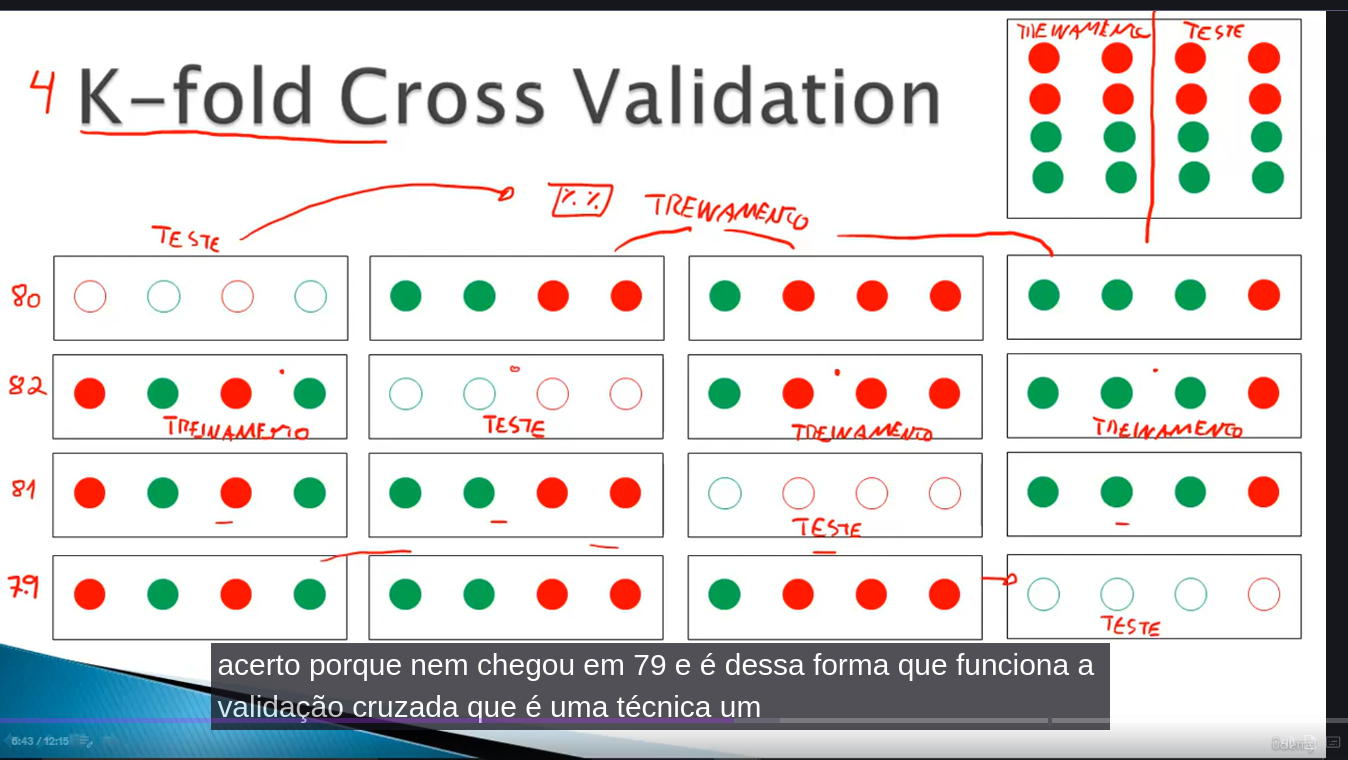

In [8]:
import numpy as np
X_credit = np.concatenate((X_credit_treinamento, X_credit_teste), axis = 0) # axi 0 é para concatenar as linhas
X_credit.shape

(32581, 3)

In [9]:
# renda, idade, dívida

X_credit

array([[8.000e+04, 2.200e+01, 7.250e+03],
       [6.700e+04, 3.000e+01, 1.000e+04],
       [5.916e+04, 2.500e+01, 1.660e+04],
       ...,
       [5.200e+04, 3.000e+01, 9.000e+03],
       [6.800e+04, 2.400e+01, 6.000e+03],
       [6.400e+04, 2.500e+01, 2.000e+04]])

In [10]:
# concatenar as respostas

y_credit = np.concatenate((y_credit_treinamento, y_credit_teste), axis = 0)
y_credit.shape

(32581,)

In [11]:
y_credit[:50] # 0 quando o cliente paga o empréstimo, e 1 quando o cliente não paga

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0])

In [12]:
# preparação dos dados finalizados

# 14.4) Ajuste dos parâmetros dos algoritmos 2

### Árvore de decisão

class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [13]:
parametros = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}  # algoritmo fará as escolhas.

Parameters:

- criterion{“gini”, “entropy”, “log_loss”}, default=”gini”
The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain, see Mathematical formulation.

- splitter{“best”, “random”}, default=”best”
The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.

max_depthint, default=None
The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

- min_samples_split int or float, default=2
The minimum number of samples required to split an internal node:

If int, then consider min_samples_split as the minimum number.

If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.

- min_samples_leaf int or float, default=1
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

If int, then consider min_samples_leaf as the minimum number.

If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.


* criterion: para calcular qual é o atributo com o maior ganho de informação. Cálculo da entropia e  impureza do gini. 

* splitter: estratégia para escolher as divisões em cada um dos nós, pode ser best ou random

* min_samples_split: número mínimo de registros requeridos para quebrar um intervalo da árvore de decisão, para ver se a divisão vai para esquerda ou direita. O padrão é 2

* min_samples_leaf: número mínim de registros requeridos para o nó ser considerado como um nó folha. 
padrão 1, parte inferior como 1 nó folha, ou pode aumentar entre 5 ou 10. 

validação cruzada

class sklearn.model_selection.GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

- estimatorestimator object
This is assumed to implement the scikit-learn estimator interface. Either estimator needs to provide a score function, or scoring must be passed.

- param_grid dict or list of dictionaries
Dictionary with parameters names (str) as keys and lists of parameter settings to try as values, or a list of such dictionaries, in which case the grids spanned by each dictionary in the list are explored. This enables searching over any sequence of parameter settings.

- cv int, cross-validation generator or an iterable, default=None
Determines the cross-validation splitting strategy. Possible inputs for cv are:

None, to use the default 5-fold cross validation,

integer, to specify the number of folds in a (Stratified)KFold,

CV splitter,

An iterable yielding (train, test) splits as arrays of indices.

For integer/None inputs, if the estimator is a classifier and y is either binary or multiclass, StratifiedKFold is used. In all other cases, KFold is used. These splitters are instantiated with shuffle=False so the splits will be the same across calls.


In [14]:

# variável grid_search, para a função da validação cruzada: GridSearchCV
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=parametros)
# estimator = modelo árvore de decisão

In [15]:
# fit X indica os atributos previsores y resposta, fit teinamento ou ajuste em todos os parâmetros
grid_search.fit(X_credit, y_credit)
# melhores parâmetros selecionados
melhores_parametros = grid_search.best_params_
# melhor acurácia
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print('melhor acurácia em {:.3f} %'.format(melhor_resultado*100)) # melhorou em comparação com os dados anteriores

{'criterion': 'entropy', 'min_samples_leaf': 10, 'min_samples_split': 2, 'splitter': 'best'}
melhor acurácia em 83.070 %


# 14.4) Ajuste dos parâmetros dos algoritmos 3 

In [16]:
# aplicar o GridSearchCV para os outros algoritmos

## Random forest



class sklearn.ensemble.RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)


https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

- n_estimators int, default=100

The number of trees in the forest.

Changed in version 0.22: The default value of n_estimators changed from 10 to 100 in 0.22.

- criterion {“gini”, “entropy”, “log_loss”}, default=”gini”
The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain, see Mathematical formulation. Note: This parameter is tree-specific.

- min_samples_split int or float, default=2
The minimum number of samples required to split an internal node:

If int, then consider min_samples_split as the minimum number.

If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.

Changed in version 0.18: Added float values for fractions.

- min_samples_leaf int or float, default=1
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

If int, then consider min_samples_leaf as the minimum number.

If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.


----

n_estimadors = número de árvores de decisão a serem geradas

critério: impureza de gini ou o cálculo da entropia. 


min_samples_split 


min_samples_leaf 

In [17]:
parametros = {'criterion': ['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [18]:
# validação cruzada, estimador modelo random forest
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print('Parâmetros escolhod como o melhor:',melhores_parametros)
print('melhor acurácia em {:.3f} %'.format(melhor_resultado*100)) # melhorou em comparação com os dados anteriores

Parâmetros escolhod como o melhor: {'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}
melhor acurácia em 84.239 %


In [19]:
#novidade, utilizando o 'min_samples_split': dois parâmetros para os melhores resultados 'min_samples_split': 10, 'n_estimators': 150

In [20]:
# GridSearchCV faz a combinação dos parâmetros

### Knn

In [21]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1, 2]}

class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


- n_neighborsint, default=5

Number of neighbors to use by default for kneighbors queries.

número de vizinhos

- p float, default=2
Power parameter for the Minkowski metric. When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used. This parameter is expected to be positive.

distância

p =2 distância eucliana

p = 1 distância manhattan

calculos diferente s para media a similaridade

In [22]:
# nome do classificador: KNeighborsClassifier
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print('Parâmetros escolhod como o melhor:',melhores_parametros)
print('melhor acurácia em {:.3f} %'.format(melhor_resultado*100)) # bom resultado, distância manhattan escolhida.

Parâmetros escolhod como o melhor: {'n_neighbors': 20, 'p': 1}
melhor acurácia em 83.960 %


### Regressão logística

In [23]:
parametros = {'tol': [0.0001, 0.00001, 0.000001],
              'C': [1.0, 1.5, 2.0],
              'solver': ['lbfgs', 'sag', 'saga']}

class sklearn.linear_model.LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

- tol float, default=1e-4
Tolerance for stopping criteria.

- C float, default=1.0
Inverse of regularization strength; must be a positive float. Like in support vector machines, smaller values specify stronger regularization.

- solver{‘lbfgs’, ‘liblinear’, ‘newton-cg’, ‘newton-cholesky’, ‘sag’, ‘saga’}, default=’lbfgs’
Algorithm to use in the optimization problem. Default is ‘lbfgs’. To choose a solver, you might want to consider the following aspects:

For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones;

For multiclass problems, all solvers except ‘liblinear’ minimize the full multinomial loss;

‘liblinear’ can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the OneVsRestClassifier.

‘newton-cholesky’ is a good choice for n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on n_features * n_classes because it explicitly computes the full Hessian matrix.

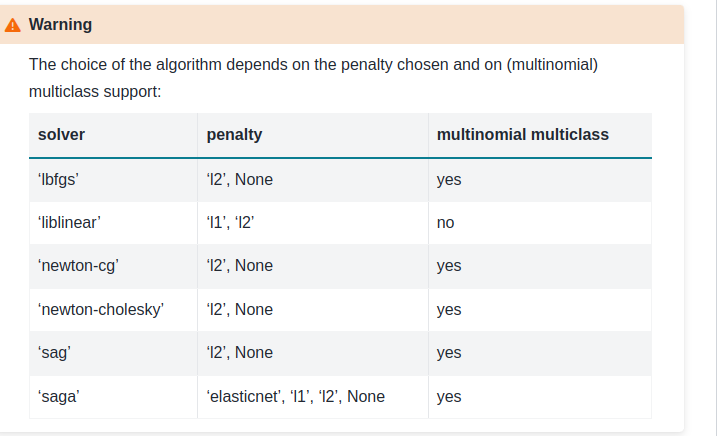

* tol= tolerância, parecida com as redes neurais

com os erros, se o valor da tol não diminuir, o modelo é parado. 

* c, svm, quanto maior, mais o algoritmo vai encaixar nos dados

* solver, algoritmo utilizado para fazer os ajustes dos valores, para encontrar os coeficientes. Coeficiente b0, e um coeficiente para cada atributo. 

Correlação solver: {‘lbfgs’, ‘liblinear’, ‘newton-cg’, ‘newton-cholesky’, ‘sag’, ‘saga’}

In [24]:
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print('Parâmetros escolhod como o melhor:',melhores_parametros)
print('melhor acurácia em {:.3f} %'.format(melhor_resultado*100)) # bom resultado;

/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home

Parâmetros escolhod como o melhor: {'C': 1.0, 'solver': 'sag', 'tol': 0.0001}
melhor acurácia em 79.460 %


/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [25]:
print('Parâmetros escolhod como o melhor:',melhores_parametros)
print('melhor acurácia em {:.3f} %'.format(melhor_resultado*100)) # bom resultado.

Parâmetros escolhod como o melhor: {'C': 1.0, 'solver': 'sag', 'tol': 0.0001}
melhor acurácia em 79.460 %


For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones;

‘sag’ and ‘saga’ fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing.



### SVM

class sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html


- C float, default=1.0
Regularization parameter. The strength of the regularization is inversely proportional to C. Must be strictly positive. The penalty is a squared l2 penalty. For an intuitive visualization of the effects of scaling the regularization parameter C, see Scaling the regularization parameter for SVCs.

- kernel {‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’} or callable, default=’rbf’
Specifies the kernel type to be used in the algorithm. If none is given, ‘rbf’ will be used. If a callable is given it is used to pre-compute the kernel matrix from data matrices; that matrix should be an array of shape (n_samples, n_samples). For an intuitive visualization of different kernel types see Plot classification boundaries with different SVM Kernels.

- tol float, default=1e-3
Tolerance for stopping criterion.

In [ ]:
parametros = {'tol': [0.001, 0.0001, 0.00001],
              'C': [1.0, 1.5, 2.0],
              'kernel': ['rbf', 'linear', 'poly', 'sigmoid']}

kernel teste

tol tolerância

quanto maior o c, melhor a tendência dop algoritmo se adaptar. 

kernel 


In [ ]:
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros) # cross validation,modelo svc
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print('Parâmetros escolhod como o melhor:',melhores_parametros)
print('melhor acurácia em {:.3f} %'.format(melhor_resultado*100)) # bom resultado.

### Redes neurais



class sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)

https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [18]:
parametros = {'activation': ['relu', 'logistic', 'tahn'],
              'solver': ['adam', 'sgd'],
              'batch_size': [10, 56]}

- activation{‘identity’, ‘logistic’, ‘tanh’, ‘relu’}, default=’relu’
Activation function for the hidden layer.

‘identity’, no-op activation, useful to implement linear bottleneck, returns f(x) = x

‘logistic’, the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).

‘tanh’, the hyperbolic tan function, returns f(x) = tanh(x).

‘relu’, the rectified linear unit function, returns f(x) = max(0, x) -> padrão


- solver{‘lbfgs’, ‘sgd’, ‘adam’}, default=’adam’
The solver for weight optimization.

‘lbfgs’ is an optimizer in the family of quasi-Newton methods.

‘sgd’ refers to stochastic gradient descent.

‘adam’ refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy Ba

For a comparison between Adam optimizer and SGD, see Compare Stochastic learning strategies for MLPClassifier.

Note: The default solver ‘adam’ works pretty well on relatively large datasets (with thousands of training samples or more) in terms of both training time and validation score. For small datasets, however, ‘lbfgs’ can converge faster and perform better.

- batch_size int, default=’auto’
Size of minibatches for stochastic optimizers. If the solver is ‘lbfgs’, the classifier will not use minibatch. When set to “auto”, batch_size=min(200, n_samples).

batch_size, quantos registros serão enviados na rede neural, para atualizar os pesos.

In [19]:
# 56 batch size, atualizações do peso serão feitos de 56 a 56 registros

In [20]:
# demora mais de 3 horasm SVC

In [21]:
# escolher os melhores parâmetros para os modelos  | CV Cross Validation - ou validação cruzada
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier # redes neurais


In [22]:
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros)


In [23]:
grid_search.fit(X_credit, y_credit)


/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the follo

GridSearchCV(estimator=MLPClassifier(),
             param_grid={'activation': ['relu', 'logistic', 'tahn'],
                         'batch_size': [10, 56], 'solver': ['adam', 'sgd']})

In [24]:
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_

In [25]:
print('Parâmetros escolhod como o melhor:',melhores_parametros)
print('melhor acurácia em {:.3f} %'.format(melhor_resultado*100)) # bom resultado. 

Parâmetros escolhod como o melhor: {'activation': 'logistic', 'batch_size': 56, 'solver': 'adam'}
melhor acurácia em 81.093 %
